## Buy Box Relationships - Descriptive Analytics  

### Objective: 
        1. To highlight the relationship between our features and the buy box win probability
        2. Leverage our intution to decide which features we should select for our causal model  
---

In [12]:
import pandas as pd 
import numpy as np  
from pathlib import Path
import matplotlib.pyplot as plt 
import statsmodels.api as sm
import seaborn as sns 
from src.utils.io import save_df
import os 

#PROJECT_ROOT = Path.cwd().resolve()
#print("Project root:", PROJECT_ROOT)

In [13]:
# load data into dataframe

df = pd.read_csv("data/synthetic/marketplace_panel.csv")
df.head()

,day,asin,seller_id,seller_rating,fulfillment_type,shipping_days,product_cost,target_price,base_demand,price,...,price_gap_to_lowest,buy_box_probability,buy_box_winner,market_demand_units,units_sold,revenue,amazon_referral_fee,fulfillment_cost,contribution_profit_per_unit,contribution_profit
0,1,A0001,S032,88.5,FBA,2,82.06,120.02,40,113.24,...,0.00,0.6786,0,49,3,339.72,16.99,5.90,8.29,24.87
1,1,A0001,S028,92.1,FBM,5,82.06,120.02,40,113.80,...,0.56,0.0874,1,49,39,4438.20,17.07,6.25,8.42,328.38
2,1,A0001,S018,86.2,FBM,3,82.06,120.02,40,115.80,...,2.56,0.0348,0,49,2,231.60,17.37,5.55,10.82,21.64
3,1,A0001,S021,91.8,FBA,2,82.06,120.02,40,115.87,...,2.63,0.1474,0,49,4,463.48,17.38,5.90,10.53,42.12
4,1,A0001,S012,93.1,FBA,2,82.06,120.02,40,118.65,...,5.41,0.0350,0,49,0,0.00,17.80,5.90,12.89,0.00


In [ ]:
df.info()

### Select Independent Features/Levers that Influence the Buy Box decisions  

|Feature|Why?|
|-|-|
|price_gap_to_lowest| captures pricing competitiveness|
|shipping_days| captures delivery time| 
|seller_rating| captures trust/qualit|
|is_fba| captures platform advantage (Prime Eligible and logistics)|  

```Features NOT Included:```

    - price_rank and lowest_price would create multicolinearity with price_gap_to_lowest variable, we are already capturing the price competitiveness with a stronger signal/feature  

  
```Note: At this point of the project, I want to start with an effcient model with a a few independent features. Future enhancements may include fixed effects to learn more about the relationships, but it's best to consider degrees of freedom before adding more features that may complicate the model``` 

In [27]:
df["is_fba"] = (df["fulfillment_type"] == "FBA").astype(int)

features = [
    "price_gap_to_lowest", #captures pricing competitiveness, continous variable
    "shipping_days", #captures delivery component
    "seller_rating", #captures seller trust/quality
    "is_fba" #captures Prime Eligible
]

X = df[features] #inputs
y = df["buy_box_winner"] #output

X = sm.add_constant(X) #baseline probability (y intercept)

In [28]:
# reviewing colinearity between shipping days and is fba
df[['shipping_days','is_fba']].corr()

,shipping_days,is_fba
shipping_days,1.000000,-0.886525
is_fba,-0.886525,1.000000


### Builiding a model that answers:
     "What is the probability a seller wins the Buy Box given these features?"

In [29]:
# Logistic Regression  
# You are teaching a model to estimate the probability of winning the Buy Box based on pricing and seller characteristics.

model = sm.Logit(y, X)
results = model.fit()  

print(results.summary())

Optimization terminated successfully.
         Current function value: 0.288599
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:         buy_box_winner   No. Observations:                74970
Model:                          Logit   Df Residuals:                    74965
Method:                           MLE   Df Model:                            4
Date:                Sat, 21 Mar 2026   Pseudo R-squ.:                  0.3879
Time:                        16:03:42   Log-Likelihood:                -21636.
converged:                       True   LL-Null:                       -35349.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -3.6203      0.273    -13.253      0.000      -4.156      -3.085
pr

### Doesn't provide causation, but: 

    - helps translate intuition into something measurable  
    - how much does price actually matter vs. shipping vs. FBA?  
    - This enables:  
      - causal thinking (notebook 5)  
      - priceing decisions (noterbook 6)

In [30]:
# saving above model results 

import pickle

with open("data/processed/buy_box_model.pkl", "wb") as f:
    pickle.dump(results, f)

In [61]:
# Converting Logistic Regression (log-odds) Coefficient to Odds Ratio to be more business friendly interpretation  

pg_coef = results.params["price_gap_to_lowest"]
sd_coef = results.params['shipping_days']
sr_coef = results.params['seller_rating']
fba_coef = results.params['is_fba']

coef_results =[pg_coef, sd_coef, sr_coef, fba_coef]
labels = ['price gap', 'shipping days', 'seller rating', 'is fba']


for l, c in zip(labels, coef_results): 
    print(f'{l} coefficient: {c.round(4)}')

print('-'*100)

for l,c in zip(labels, coef_results):
    print(f'{l} odd ratio: {(np.exp(c)).round(4)}')

print('-'*100)

for l,c in zip(labels, coef_results):
    print(f'{l} probability interpretation: {(np.exp(c)-1).round(4)}')


price gap coefficient: -0.7732
shipping days coefficient: -0.3436
seller rating coefficient: 0.0459
is fba coefficient: 0.5418
----------------------------------------------------------------------------------------------------
price gap odd ratio: 0.4615
shipping days odd ratio: 0.7092
seller rating odd ratio: 1.047
is fba odd ratio: 1.7191
----------------------------------------------------------------------------------------------------
price gap probability interpretation: -0.5385
shipping days probability interpretation: -0.2908
seller rating probability interpretation: 0.047
is fba probability interpretation: 0.7191


### Feature Interpretation  

|feature|interpretation|
|-|-|
|price gap|Each $1 price increase REDUCES Buy Box Winning odds by ~54%|
|shipping days|Each additional day of shipping REDUCES Buy Box Winning odds by ~29%|
|seller rating|A 1-point increase in rating INCREASES Buy Box Winning odds by 5%|
|is fba| FBA sellers have a 72% HIGHER odds of winnning the Buy Box|


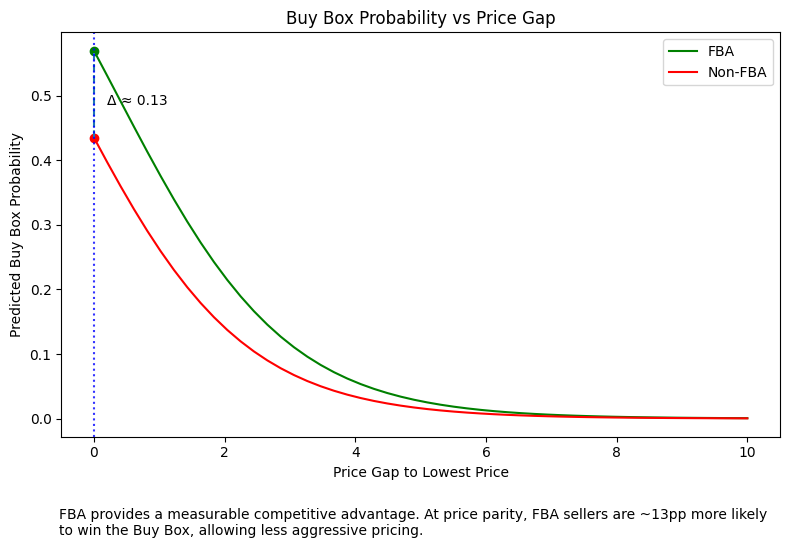

In [58]:
price_range = np.linspace(0, 10, 50)

# --- FBA (green) ---
X_fba = pd.DataFrame({
    "const": 1,
    "price_gap_to_lowest": price_range,
    "shipping_days": df["shipping_days"].mean(),
    "seller_rating": df["seller_rating"].mean(),
    "is_fba": 1
})

pred_fba = results.predict(X_fba)

# --- Non-FBA (red) ---
X_non_fba = pd.DataFrame({
    "const": 1,
    "price_gap_to_lowest": price_range,
    "shipping_days": df["shipping_days"].mean(),
    "seller_rating": df["seller_rating"].mean(),
    "is_fba": 0
})

pred_non_fba = results.predict(X_non_fba)

# find index closest to 0
idx_zero = np.argmin(np.abs(price_range - 0))

p_fba_0 = pred_fba[idx_zero]
p_non_fba_0 = pred_non_fba[idx_zero]

delta = p_fba_0 - p_non_fba_0

# --- Plot ---
plt.figure(figsize=(8,5))

plt.plot(price_range, pred_fba, color="green", label="FBA")
plt.plot(price_range, pred_non_fba, color="red", label="Non-FBA")

# mark the points
plt.scatter(0, p_fba_0, color="green")
plt.scatter(0, p_non_fba_0, color="red")

# draw a vertical line between them
plt.plot([0, 0], [p_non_fba_0, p_fba_0], linestyle="--")

plt.title("Buy Box Probability vs Price Gap")
plt.xlabel("Price Gap to Lowest Price")
plt.ylabel("Predicted Buy Box Probability")
plt.legend()

plt.text(
    0.2, 
    (p_fba_0 + p_non_fba_0) / 2, 
    f"Δ ≈ {delta:.2f}",
    verticalalignment="top"
)

plt.axvline(0, linestyle=":", alpha=0.8, color='blue')

plt.tight_layout()

plt.gcf().text(
    0.08, -0.08,
    "FBA provides a measurable competitive advantage. At price parity, FBA sellers are ~13pp more likely\nto win the Buy Box, allowing less aggressive pricing.",
    ha='left',
    fontsize=10
)

plt.show()

---